<a href="https://colab.research.google.com/github/Preksha-Dadoo/Traffic-Prediction-Using-Sensor-Data/blob/main/Traffic_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
pip install pandas numpy scikit-learn xgboost matplotlib seaborn

In [7]:
#Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import seaborn as sns

In [8]:
# Loading dataset
df = pd.read_csv('/content/Metro_Interstate_Traffic_Volume.csv')

#Data Cleaning and Noise Removal

In [9]:
# Filling missing 'holiday' with 'None'
df['holiday'] = df['holiday'].fillna('None')

# Converting 'date_time' to datetime format
df['date_time'] = pd.to_datetime(df['date_time'])

In [10]:
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,None,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,None,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,None,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,None,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,None,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


#Feature Engineering

In [11]:
# Extracting useful features
df['hour'] = df['date_time'].dt.hour
df['day'] = df['date_time'].dt.day
df['weekday'] = df['date_time'].dt.weekday
df['month'] = df['date_time'].dt.month
df['year'] = df['date_time'].dt.year
df['is_weekend'] = df['weekday'].apply(lambda x: 1 if x >= 5 else 0)

In [12]:
# Droping original date_time column
df.drop(['date_time'], axis=1, inplace=True)

# One-hot encoding categorical columns
df = pd.get_dummies(df, columns=['holiday', 'weather_main', 'weather_description'], drop_first=True)

In [13]:
# Defining features (X) and target (y)
X = df.drop('traffic_volume', axis=1)
y = df['traffic_volume']

In [14]:
# Spliting dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
# Training Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

In [16]:
# Training XGBoost Regressor
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

In [17]:
# # Evaluation Function
# def evaluate(model_name, y_true, y_pred):
#     print(f"--- {model_name} ---")
#     print("R² Score:", r2_score(y_true, y_pred))
#     print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
#     print()

#Evaluation metrics

In [18]:
# Accuracy metrics for Random Forest
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_mse = mean_squared_error(y_test, rf_preds)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_preds)

print("Random Forest Performance:")
print(f"MAE: {rf_mae:.2f}")
print(f"MSE: {rf_mse:.2f}")
print(f"RMSE: {rf_rmse:.2f}")
print(f"R² Score: {rf_r2:.4f}")
print("")

# Accuracy metrics for XGBoost
xgb_mae = mean_absolute_error(y_test, xgb_preds)
xgb_mse = mean_squared_error(y_test, xgb_preds)
xgb_rmse = np.sqrt(xgb_mse)
xgb_r2 = r2_score(y_test, xgb_preds)

print("XGBoost Performance:")
print(f"MAE: {xgb_mae:.2f}")
print(f"MSE: {xgb_mse:.2f}")
print(f"RMSE: {xgb_rmse:.2f}")
print(f"R² Score: {xgb_r2:.4f}")

Random Forest Performance:
MAE: 203.41
MSE: 140773.56
RMSE: 375.20
R² Score: 0.9644

XGBoost Performance:
MAE: 225.61
MSE: 142941.28
RMSE: 378.08
R² Score: 0.9638


In [19]:
# # Evaluate both models
# evaluate("Random Forest", y_test, rf_preds)
# evaluate("XGBoost", y_test, xgb_preds)

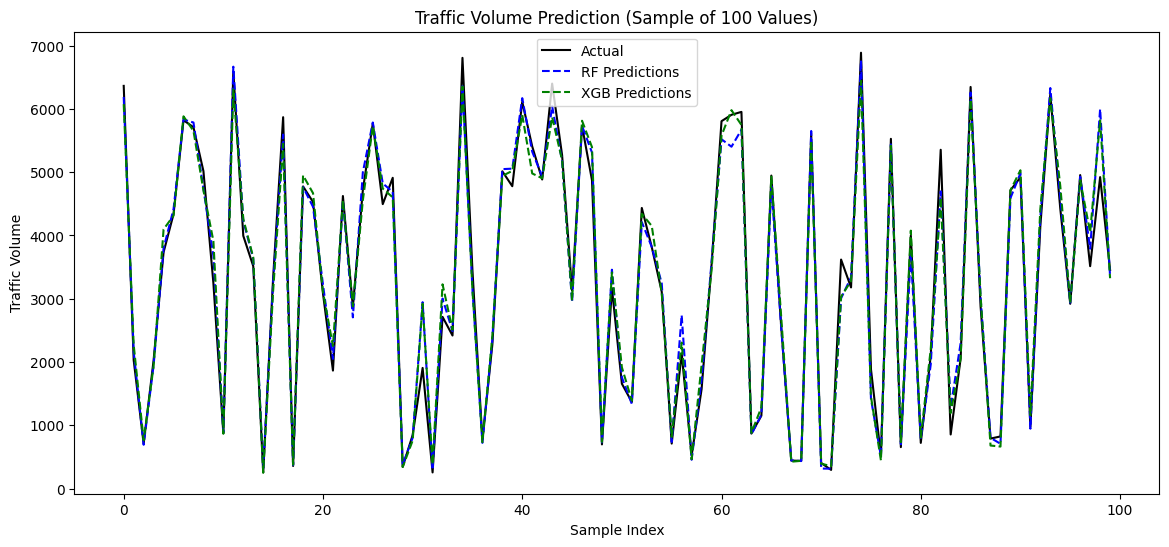

In [20]:
# Visualization of Predictions vs Actual
plt.figure(figsize=(14,6))
plt.plot(y_test.values[:100], label='Actual', color='black')
plt.plot(rf_preds[:100], label='RF Predictions', linestyle='--', color='blue')
plt.plot(xgb_preds[:100], label='XGB Predictions', linestyle='--', color='green')
plt.title("Traffic Volume Prediction (Sample of 100 Values)")
plt.xlabel("Sample Index")
plt.ylabel("Traffic Volume")
plt.legend()
plt.show()


In [21]:
#Loading output to another csv file
output_df = pd.DataFrame({
    'Actual': y_test.values,
    'RF_Pred': rf_preds,
    'XGB_Pred': xgb_preds
})
output_df.to_csv("traffic_predictions_output.csv", index=False)

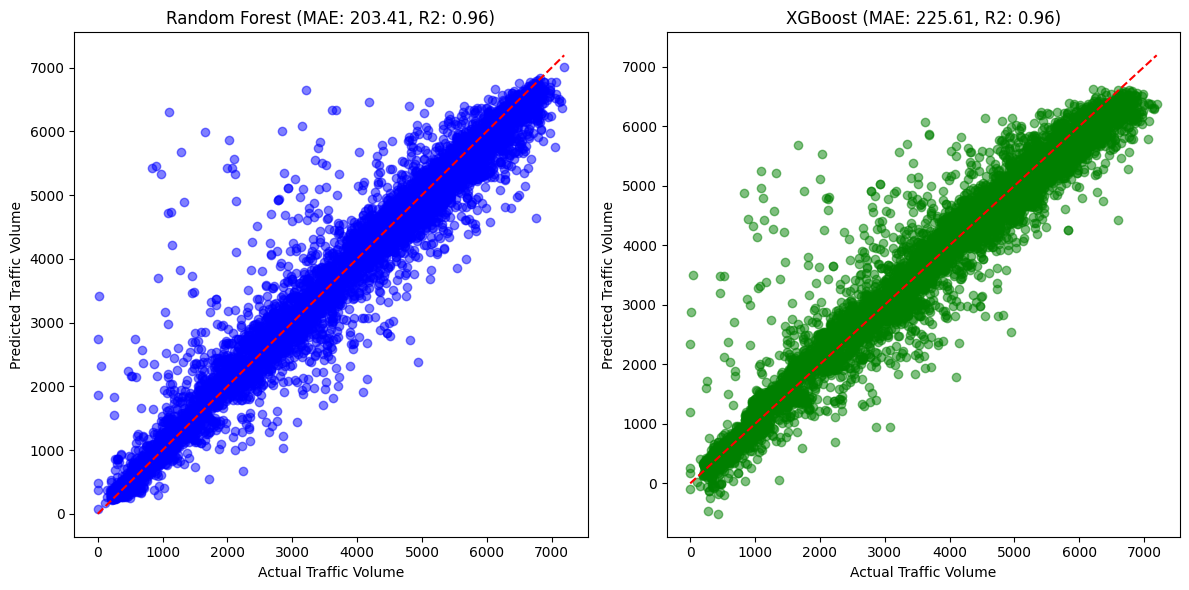

In [22]:
# Plot comparison of actual vs predicted traffic volume for both models
plt.figure(figsize=(12, 6))

# Plot Random Forest Predictions
plt.subplot(1, 2, 1)
plt.scatter(y_test, rf_preds, color='blue', alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.title(f'Random Forest (MAE: {rf_mae:.2f}, R2: {rf_r2:.2f})')
plt.xlabel('Actual Traffic Volume')
plt.ylabel('Predicted Traffic Volume')

# Plot XGBoost Predictions
plt.subplot(1, 2, 2)
plt.scatter(y_test, xgb_preds, color='green', alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.title(f'XGBoost (MAE: {xgb_mae:.2f}, R2: {xgb_r2:.2f})')
plt.xlabel('Actual Traffic Volume')
plt.ylabel('Predicted Traffic Volume')

plt.tight_layout()
plt.show()
